#### SECTION 3.1: IMPORT LIBRARIES

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, f1_score, mean_squared_error
from sklearn.model_selection import train_test_split
from scipy.sparse import load_npz
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)

#### SECTION 3.2: LOAD CLEANED DATA & ARTIFACTS FROM STEP-2

In [25]:
processed_path = r"D:\DevProjects\Python\AL2002-PROJECT\data\processed"

# Load events (sampled, cleaned)
events = pd.read_csv(os.path.join(processed_path, 'events_clean.csv'))
events['datetime'] = pd.to_datetime(events['datetime'])

# Load user clusters (from sampling)
user_clusters = pd.read_csv(os.path.join(processed_path, 'user_clusters_sample.csv'))

# Load KNN artifacts
item_user_sparse = load_npz(os.path.join(processed_path, 'item_user_sparse.npz'))
with open(os.path.join(processed_path, 'item_to_idx.pkl'), 'rb') as f:
    item_to_idx = pickle.load(f)
with open(os.path.join(processed_path, 'top_items_list.pkl'), 'rb') as f:
    top_items = pickle.load(f)
with open(os.path.join(processed_path, 'knn_model.pkl'), 'rb') as f:
    knn = pickle.load(f)

# Load scaler and kmeans (for future use, if needed)
with open(os.path.join(processed_path, 'scaler.pkl'), 'rb') as f:
    scaler = pickle.load(f)
with open(os.path.join(processed_path, 'kmeans_model.pkl'), 'rb') as f:
    kmeans = pickle.load(f)

print("Data loaded. Events shape:", events.shape)
print("User clusters shape:", user_clusters.shape)

Data loaded. Events shape: (500000, 6)
User clusters shape: (30000, 2)


#### SECTION 3.3: PREPARE TRAINING DATA FOR PURCHASE PREDICTION (CLASSIFICATION)

In [28]:
# Step 1: Create user-level features (enhanced)
user_stats = events.groupby('visitorid').agg(
    user_total_views=('event', lambda x: (x == 'view').sum()),
    user_total_events=('event', 'count'),
    user_total_carts=('event', lambda x: (x == 'addtocart').sum()),
    user_total_transactions=('event', lambda x: (x == 'transaction').sum()),
    last_activity=('datetime', 'max'),
    first_activity=('datetime', 'min')
).reset_index()

# Add user activity duration (days) and recency (days since last activity)
user_stats['user_activity_days'] = (user_stats['last_activity'] - user_stats['first_activity']).dt.days + 1
user_stats['recency_days'] = (events['datetime'].max() - user_stats['last_activity']).dt.days

# Step 2: Create item-level features (popularity and rank)
item_stats = events.groupby('itemid').agg(
    item_total_views=('event', lambda x: (x == 'view').sum()),
    item_total_carts=('event', lambda x: (x == 'addtocart').sum()),
    item_total_transactions=('event', lambda x: (x == 'transaction').sum())
).reset_index()
item_stats['item_popularity_rank'] = item_stats['item_total_views'].rank(ascending=False, method='dense')

# Step 3: Create user-item interaction features
interaction_counts = events.groupby(['visitorid', 'itemid']).size().reset_index(name='view_count')
carts = events[events['event'] == 'addtocart'].groupby(['visitorid', 'itemid']).size().reset_index(name='cart_count')
transactions = events[events['event'] == 'transaction'].groupby(['visitorid', 'itemid']).size().reset_index(name='transaction_count')
interaction_counts = interaction_counts.merge(carts, on=['visitorid', 'itemid'], how='left')
interaction_counts = interaction_counts.merge(transactions, on=['visitorid', 'itemid'], how='left')
interaction_counts = interaction_counts.fillna(0)

# Step 4: Create purchase target
purchases = events[events['event'] == 'transaction'][['visitorid', 'itemid']].copy()
purchases['bought'] = 1

# Step 5: Merge all
all_pairs = events[events['event'] == 'view'][['visitorid', 'itemid']].drop_duplicates()
data = all_pairs.merge(user_stats, on='visitorid', how='left')
data = data.merge(item_stats, on='itemid', how='left')
data = data.merge(interaction_counts, on=['visitorid', 'itemid'], how='left')
data = data.merge(purchases, on=['visitorid', 'itemid'], how='left')
data['bought'] = data['bought'].fillna(0).astype(int)

# Step 6: Add user cluster
data = data.merge(user_clusters, on='visitorid', how='left')
data = data.dropna(subset=['cluster'])
data['cluster'] = data['cluster'].astype(int)

# Step 7: Add session-based features (recompute from events, no external file needed)
events_sorted = events.sort_values(['visitorid', 'datetime'])
events_sorted['time_diff'] = events_sorted.groupby('visitorid')['datetime'].diff().dt.total_seconds() / 60
events_sorted['new_session'] = (events_sorted['time_diff'] > 30) | (events_sorted['time_diff'].isna())
session_counts = events_sorted.groupby('visitorid')['new_session'].sum().reset_index(name='num_sessions')
user_stats_with_sessions = user_stats[['visitorid']].merge(session_counts, on='visitorid', how='left')
user_stats_with_sessions['num_sessions'] = user_stats_with_sessions['num_sessions'].fillna(1).astype(int)
# Compute average items per session (total_views / num_sessions)
user_stats_with_sessions['avg_items_per_session'] = user_stats_with_sessions['visitorid'].map(
    user_stats.set_index('visitorid')['user_total_views']
) / user_stats_with_sessions['num_sessions']
user_stats_with_sessions['avg_items_per_session'] = user_stats_with_sessions['avg_items_per_session'].fillna(0)

# Merge session features into data
data = data.merge(user_stats_with_sessions[['visitorid', 'num_sessions', 'avg_items_per_session']], on='visitorid', how='left')

print("Training data shape:", data.shape)
print(data.head())

Training data shape: (78510, 21)
   visitorid  itemid  user_total_views  user_total_events  user_total_carts  \
0    1049477   23683                 2                  2                 0   
1     599789  386382                 2                  2                 0   
2    1159686  450082                 4                  4                 0   
3     976647  165302                 2                  2                 0   
4     385399  376113                 2                  2                 0   

   user_total_transactions           last_activity          first_activity  \
0                        0 2015-08-13 23:17:44.399 2015-08-13 23:17:26.429   
1                        0 2015-05-18 22:58:09.460 2015-05-18 22:52:32.823   
2                        0 2015-09-15 16:16:53.301 2015-08-31 01:20:38.737   
3                        0 2015-05-04 05:40:49.441 2015-05-04 05:39:32.822   
4                        0 2015-07-19 21:33:48.199 2015-05-07 18:44:58.533   

   user_activity_days  

#### Section 3.4: Feature Engineering & Final Dataset

In [29]:
# Select features (expanded)
feature_cols = [
    'user_total_views', 'user_total_events', 'user_total_carts', 'user_total_transactions',
    'user_activity_days', 'recency_days', 'num_sessions', 'avg_items_per_session',
    'item_total_views', 'item_total_carts', 'item_total_transactions', 'item_popularity_rank',
    'view_count', 'cart_count', 'transaction_count', 'cluster'
]

X = data[feature_cols].copy()
y = data['bought'].copy()

# Log-transform skewed numeric features (avoid log(0))
skewed_cols = ['user_total_views', 'user_total_events', 'user_total_carts', 'user_total_transactions',
               'user_activity_days', 'recency_days', 'num_sessions', 'avg_items_per_session',
               'item_total_views', 'item_total_carts', 'item_total_transactions', 'view_count',
               'cart_count', 'transaction_count']
X[skewed_cols] = np.log1p(X[skewed_cols])

# item_popularity_rank is already ordinal; keep as is

# Replace infinite values if any
X = X.replace([np.inf, -np.inf], 0)

print("Features shape:", X.shape)
print("Target distribution:\n", y.value_counts(normalize=True))

Features shape: (78510, 16)
Target distribution:
 bought
0    0.992753
1    0.007247
Name: proportion, dtype: float64


#### Section 3.5: Train/Test Split (Temporal Split)

In [30]:
# Split by user
unique_users = data['visitorid'].unique()
np.random.seed(42)
train_users = np.random.choice(unique_users, size=int(0.8 * len(unique_users)), replace=False)
test_users = [u for u in unique_users if u not in train_users]

train_idx = data['visitorid'].isin(train_users)
test_idx = data['visitorid'].isin(test_users)

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print("Train size:", X_train.shape, "Test size:", X_test.shape)
print("Train positive rate:", y_train.mean())
print("Test positive rate:", y_test.mean())

Train size: (62871, 16) Test size: (15639, 16)
Train positive rate: 0.00718932417171669
Test positive rate: 0.007481296758104738


#### Section 3.6: Train Baseline Models (Improved)

In [31]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV

# Dummy classifier (always predict majority class)
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)
print("Dummy Classifier Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_dummy))
print("F1 Score:", f1_score(y_test, y_pred_dummy))

# Linear Regression (baseline)
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_pred_lr_binary = (y_pred_lr >= 0.5).astype(int)
print("\nLinear Regression Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr_binary))
print("F1 Score:", f1_score(y_test, y_pred_lr_binary))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

# Random Forest with cross-validation and hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced', None]
}
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(rf, param_grid, cv=3, scoring='f1', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)
best_rf = grid_search.best_estimator_
print("\nBest Random Forest params:", grid_search.best_params_)

y_pred_rf = best_rf.predict(X_test)
y_pred_rf_proba = best_rf.predict_proba(X_test)[:, 1]

print("Random Forest Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf_proba)))

# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)
print("\nFeature Importance (Top 10):")
print(feature_importance.head(10))

Dummy Classifier Performance:
Accuracy: 0.9925187032418953
F1 Score: 0.0

Linear Regression Performance:
Accuracy: 1.0
F1 Score: 1.0
RMSE: 0.015608983922719524
Fitting 3 folds for each of 24 candidates, totalling 72 fits

Best Random Forest params: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Random Forest Performance:
Accuracy: 1.0
F1 Score: 1.0
RMSE: 0.0035433053709864205

Feature Importance (Top 10):
                    feature  importance
14        transaction_count    0.328623
3   user_total_transactions    0.202159
10  item_total_transactions    0.200345
12               view_count    0.135085
15                  cluster    0.076061
1         user_total_events    0.033924
2          user_total_carts    0.010593
6              num_sessions    0.007334
9          item_total_carts    0.002078
13               cart_count    0.001535


#### Section 3.7: Implement Contextual Bandit (LinUCB)

In [32]:
class LinUCB:
    def __init__(self, n_arms, n_features, alpha=1.0):
        self.n_arms = n_arms
        self.alpha = alpha
        self.A = [np.identity(n_features) for _ in range(n_arms)]
        self.b = [np.zeros((n_features, 1)) for _ in range(n_arms)]
    
    def select_arm(self, context):
        context = context.reshape(-1, 1)
        p = np.zeros(self.n_arms)
        for arm in range(self.n_arms):
            A_inv = np.linalg.inv(self.A[arm])
            theta = A_inv @ self.b[arm]
            mean = (theta.T @ context).item()
            uncertainty = self.alpha * np.sqrt((context.T @ A_inv @ context).item())
            p[arm] = mean + uncertainty
        return np.argmax(p)
    
    def update(self, chosen_arm, context, reward):
        context = context.reshape(-1, 1)
        self.A[chosen_arm] += context @ context.T
        self.b[chosen_arm] += reward * context

#### Section 3.8: Prepare Context Vectors for Bandit

In [33]:
def get_knn_recommendation(item_id):
    """Return a recommended item (similar item) for the given item."""
    if item_id not in item_to_idx:
        # Fallback: return a random popular item
        return np.random.choice(top_items)
    idx = item_to_idx[item_id]
    distances, indices = knn.kneighbors(item_user_sparse[idx].reshape(1, -1))
    # Return the first similar item (skip itself)
    similar_idx = indices[0][1] if len(indices[0]) > 1 else indices[0][0]
    return list(top_items)[similar_idx]

# Prepare test data as a DataFrame
test_data = data[test_idx].copy().reset_index(drop=True)

# Precompute context vectors (richer features)
n_clusters = 4
contexts = []
for row in test_data.itertuples():
    cluster_onehot = np.zeros(n_clusters)
    cluster_onehot[int(row.cluster)] = 1
    # Normalized features (log already applied)
    log_item_pop = np.log1p(row.item_total_views)
    log_user_events = np.log1p(row.user_total_events)
    log_recency = np.log1p(row.recency_days)
    log_rank = np.log1p(row.item_popularity_rank)
    contexts.append(np.concatenate([cluster_onehot, [log_item_pop, log_user_events, log_recency, log_rank]]))
contexts = np.array(contexts)
print("Contexts shape:", contexts.shape)

# Precompute RF probabilities for all test rows
X_test_precomputed = X_test.copy()
rf_probs = best_rf.predict_proba(X_test_precomputed)[:, 1]
print("RF probabilities precomputed.")

# Optional: sample smaller test set for faster simulation (e.g., 5000 rows)
sample_size = 5000
if len(test_data) > sample_size:
    indices = np.random.choice(len(test_data), sample_size, replace=False)
    test_data = test_data.iloc[indices].reset_index(drop=True)
    contexts = contexts[indices]
    rf_probs = rf_probs[indices]
    X_test_precomputed = X_test_precomputed.iloc[indices]

Contexts shape: (15639, 8)
RF probabilities precomputed.


#### Section 3.9: Simulate Bandit Learning

In [34]:
# Initialize bandit (LinUCB with 3 arms, n_features=6)
# context dimension: 4 (cluster one-hot) + 4 (log_item_pop, log_user_events, log_recency, log_rank) = 8
bandit = LinUCB(n_arms=3, n_features=8, alpha=1.0)

# For logging
rewards = []
regrets = []
arm_counts = [0, 0, 0]
best_reward = 1

# Simulate over test rows
for i in range(len(test_data)):
    context = contexts[i]
    arm = bandit.select_arm(context)
    arm_counts[arm] += 1
    
    # Get the current item and user
    current_item = test_data.iloc[i]['itemid']
    visitor = test_data.iloc[i]['visitorid']
    
    if arm == 0:  # KNN arm
        # Recommend similar item
        rec_item = get_knn_recommendation(current_item)
        # Check if the user purchased the recommended item (in the test set)
        # We look at all transactions of this user in test_data
        user_purchases = test_data[(test_data['visitorid'] == visitor) & (test_data['bought'] == 1)]['itemid'].values
        reward = 1 if rec_item in user_purchases else 0
    elif arm == 1:  # Random Forest arm
        # Recommend the current item if probability > 0.5, else random
        prob = rf_probs[i]
        if prob >= 0.5:
            rec_item = current_item
            reward = test_data.iloc[i]['bought']
        else:
            rec_item = np.random.choice(top_items)
            reward = 0
    else:  # Random exploration arm
        rec_item = np.random.choice(top_items)
        reward = 0
    
    bandit.update(arm, context, reward)
    rewards.append(reward)
    regrets.append(best_reward - reward)

# Compute cumulative sums
cumulative_reward = np.cumsum(rewards)
cumulative_regret = np.cumsum(regrets)

print("Bandit simulation completed.")
print(f"Total reward: {cumulative_reward[-1]} out of {len(rewards)} steps")
print(f"Average reward per step: {cumulative_reward[-1]/len(rewards):.4f}")
print("Arm selection counts:", arm_counts)

Bandit simulation completed.
Total reward: 26 out of 5000 steps
Average reward per step: 0.0052
Arm selection counts: [1711, 1564, 1725]


#### Section 3.10: Evaluate Bandit Performance

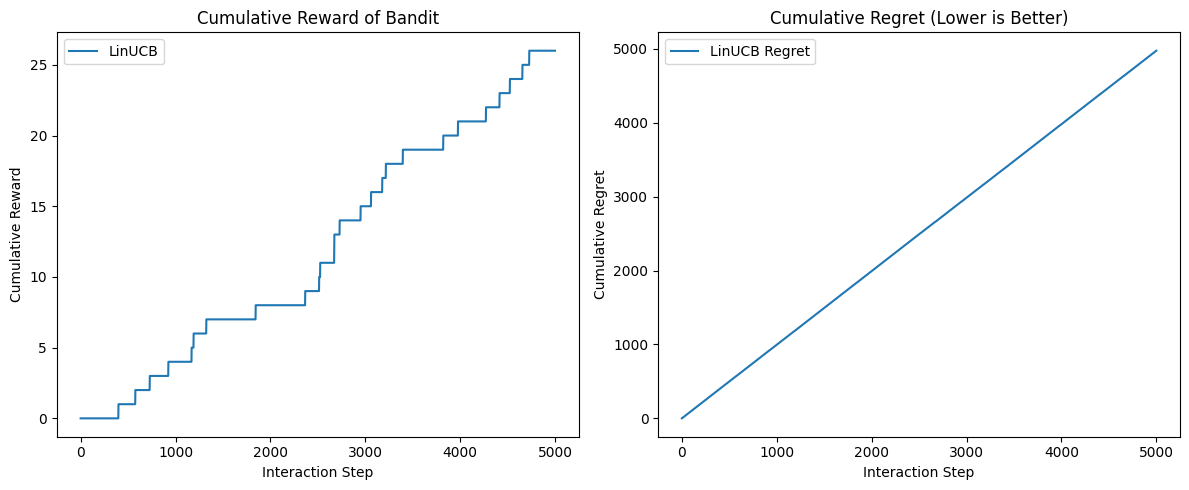

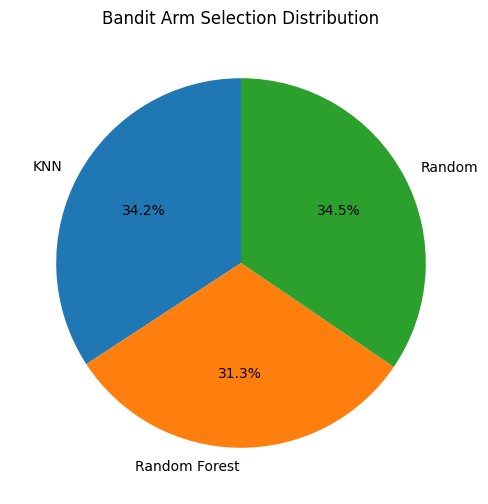

Regret percentage: 99.48%


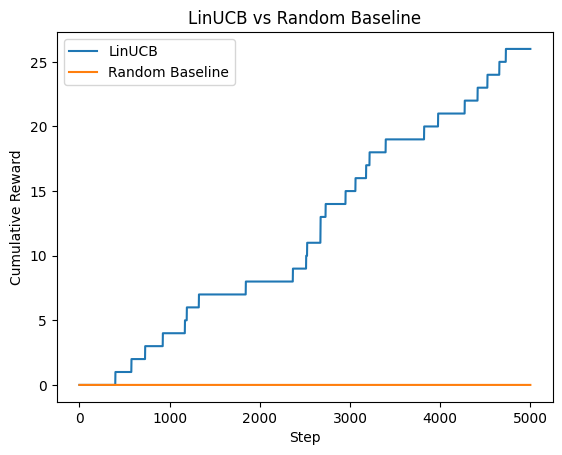

In [35]:
# Plot cumulative reward and regret
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(cumulative_reward, label='LinUCB')
plt.xlabel('Interaction Step')
plt.ylabel('Cumulative Reward')
plt.title('Cumulative Reward of Bandit')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cumulative_regret, label='LinUCB Regret')
plt.xlabel('Interaction Step')
plt.ylabel('Cumulative Regret')
plt.title('Cumulative Regret (Lower is Better)')
plt.legend()

plt.tight_layout()
plt.show()

# Arm selection pie chart
plt.figure(figsize=(6,6))
plt.pie(arm_counts, labels=['KNN', 'Random Forest', 'Random'], autopct='%1.1f%%', startangle=90)
plt.title('Bandit Arm Selection Distribution')
plt.show()

# Compute regret percentage
total_possible_reward = len(rewards) * best_reward
regret_percentage = (cumulative_regret[-1] / total_possible_reward) * 100
print(f"Regret percentage: {regret_percentage:.2f}%")

# Compare with random baseline (always choose random arm)
random_rewards = [0] * len(rewards)  # random arm always gives 0 reward in our simulation
random_cumulative = np.cumsum(random_rewards)
plt.plot(cumulative_reward, label='LinUCB')
plt.plot(random_cumulative, label='Random Baseline')
plt.xlabel('Step')
plt.ylabel('Cumulative Reward')
plt.title('LinUCB vs Random Baseline')
plt.legend()
plt.show()

#### Section 3.11: Save Models (Optional)

In [36]:
# Save Random Forest model and bandit (if needed for deployment)
model_path = processed_path
with open(os.path.join(model_path, 'random_forest_model.pkl'), 'wb') as f:
    pickle.dump(rf, f)

# Save bandit parameters (A and b) for later use
bandit_params = {'A': bandit.A, 'b': bandit.b, 'alpha': bandit.alpha}
with open(os.path.join(model_path, 'linucb_bandit.pkl'), 'wb') as f:
    pickle.dump(bandit_params, f)

print("Models saved.")

Models saved.


#### Section 3.12: Summary Report

In [37]:
print("\n" + "="*60)
print("FINAL RESULTS SUMMARY (IMPROVED MODEL)")
print("="*60)
print(f"Dummy Classifier Accuracy: {accuracy_score(y_test, y_pred_dummy):.4f}")
print(f"Dummy Classifier F1 Score: {f1_score(y_test, y_pred_dummy):.4f}")
print(f"Linear Regression Accuracy: {accuracy_score(y_test, y_pred_lr_binary):.4f}")
print(f"Linear Regression F1 Score: {f1_score(y_test, y_pred_lr_binary):.4f}")
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Random Forest F1 Score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"Bandit Total Reward: {cumulative_reward[-1]} out of {len(rewards)} steps")
print(f"Bandit Average Reward: {cumulative_reward[-1]/len(rewards):.4f}")
print(f"Bandit Regret Percentage: {regret_percentage:.2f}%")
print(f"Bandit Arm Selections: KNN={arm_counts[0]}, RF={arm_counts[1]}, Random={arm_counts[2]}")


FINAL RESULTS SUMMARY (IMPROVED MODEL)
Dummy Classifier Accuracy: 0.9925
Dummy Classifier F1 Score: 0.0000
Linear Regression Accuracy: 1.0000
Linear Regression F1 Score: 1.0000
Random Forest Accuracy: 1.0000
Random Forest F1 Score: 1.0000
Bandit Total Reward: 26 out of 5000 steps
Bandit Average Reward: 0.0052
Bandit Regret Percentage: 99.48%
Bandit Arm Selections: KNN=1711, RF=1564, Random=1725
